In [4]:
!cat /etc/os-release
print()
!ls -a
print()
!df -h # disc 사용량
print()
!free -h # 메모리 사용량
print()
!nvidia-smi # gpu 확인

PRETTY_NAME="Ubuntu 22.04.5 LTS"
NAME="Ubuntu"
VERSION_ID="22.04"
VERSION="22.04.5 LTS (Jammy Jellyfish)"
VERSION_CODENAME=jammy
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=jammy

.  ..  .config	sample_data

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   43G   70G  39% /
tmpfs            64M     0   64M   0% /dev
shm             5.7G     0  5.7G   0% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
/dev/sda1       119G   48G   72G  41% /kaggle/input
tmpfs           6.4G   84K  6.4G   1% /var/colab
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware

               total        used        free      shared  buff/cache   available
Mem:         

In [12]:
# MNIST dataset으로 CNN 실습
import tensorflow as tf
print(tf.__version__) # 2.20.0
import numpy as np
import matplotlib.pyplot as plt

# 1) 데이터 준비
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
# print(x_train[0])
print(x_train.shape) # (60000, 28, 28)

# 채널(channel) 추가 (흑백인 경우 1) -> 구조 변경후(3차원 -> 4차원 : CNN이 필요한 차원으로 변경) 정규화
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
print(x_train.shape) # (60000, 28, 28, 1)



2.20.0
(60000, 28, 28)
(60000, 28, 28, 1)


In [20]:
# 2) 모델 정의
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    # convolution - 이미지 특징 찾기
    tf.keras.layers.Conv2D(
        filters=16,         # (3,3) 사이즈의 filter 16를 동시에 사용하겠다
        kernel_size=(3,3), #  사이즈가 같은경우 kernel_size=3 가능
        padding='same',
        activation='relu'
        ),

    # Pooling - 원본이미지 pooling사이즈(2,2) MAX값으로 크기 줄이기
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)), # 사이즈가 같은 경우 pool_size = 2 가능

    tf.keras.layers.Dropout(rate=0.2), # 과적합 방지용

    # convolution2 - 이미지 특징 찾기
    tf.keras.layers.Conv2D(
        filters=32,         # (3,3) 사이즈의 filter 16를 동시에 사용하겠다
        kernel_size=(3,3), #  사이즈가 같은경우 kernel_size=3 가능
        padding='same',
        activation='relu'
        ),
    # Pooling2 - 원본이미지 pooling사이즈(2,2) MAX값으로 크기 줄이기
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)), # 사이즈가 같은 경우 pool_size = 2 가능
    tf.keras.layers.Dropout(rate=0.2), # 과적합 방지용

    # FC layer(Fully Connected Layer) - 1차원으로 구조 변경
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dropout(rate=0.3),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=10, activation='softmax')
])
model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,626 (420.41 KB)

 Trainable params: 107,626 (420.41 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# 3) compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
hist = model.fit(
    x_train, y_train, epochs=100, batch_size=128, validation_split=0.1, callbacks=[es], verbose=1
)
# Err수정시 수정한 셀만 다시 시작하면 되지만 계속 반복하면 성능이 좋아진다 성능확인을 위해서는 처음부터 다시 돌려야함!

Epoch 1/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.7903 - loss: 0.6466 - val_accuracy: 0.9730 - val_loss: 0.1058
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9343 - loss: 0.2237 - val_accuracy: 0.9805 - val_loss: 0.0670
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9531 - loss: 0.1628 - val_accuracy: 0.9838 - val_loss: 0.0542
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9611 - loss: 0.1351 - val_accuracy: 0.9865 - val_loss: 0.0494
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9678 - loss: 0.1137 - val_accuracy: 0.9888 - val_loss: 0.0421
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9707 - loss: 0.1039 - val_accuracy: 0.9883 - val_loss: 0.0423
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9735 - loss: 0.0955 - val_accuracy: 0.9897 - val_loss: 0.0364
Epoch 8/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9755 - loss: 0.0866 - val_ac

In [23]:
# 4) 모델 평가하기 (train, test평가 점수의 차이가 크면 overfitting 의심)
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
print(f'train loss : {train_loss:.4f}, train_acc : {train_acc:.4f}')

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'test loss : {train_loss:.4f}, test_acc : {train_acc:.4f}')

train loss : 0.0199, train_acc : 0.9941
test loss : 0.0199, test_acc : 0.9941


In [24]:
# 5) 모델 저장 및 재로딩
SAVE_PATH = 'cnn1model.keras'
model.save(SAVE_PATH)
print(f'모델 저장 {SAVE_PATH}')

모델 저장 cnn1model.keras


In [26]:
loaded_model = tf.keras.models.load_model(SAVE_PATH)
test_loss, test_acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f'[Reloaded]test loss : {train_loss:.4f}, [Reloaded]test_acc : {train_acc:.4f}')

[Reloaded]test loss : 0.0199, [Reloaded]test_acc : 0.9941


In [35]:
# 6) 분류 예측하기
idx = 0
x_one = x_test[idx:idx + 1]
y_true = int(y_test[idx])
# print(x_one)
print(y_true) # 7

probs = loaded_model.predict(x_one, verbose=0)[0]
print(f'probs : {probs}')
y_pred = int(np.argmax(probs))
print(f'실제값:{y_pred} ,예측값:{y_pred}')

7
probs : [1.6100555e-15 1.2934442e-08 3.3706193e-09 2.1869932e-08 2.0808375e-12
 8.8436128e-14 1.9792199e-19 9.9999988e-01 4.0767407e-12 1.5269356e-07]
실제값:7 ,예측값:7


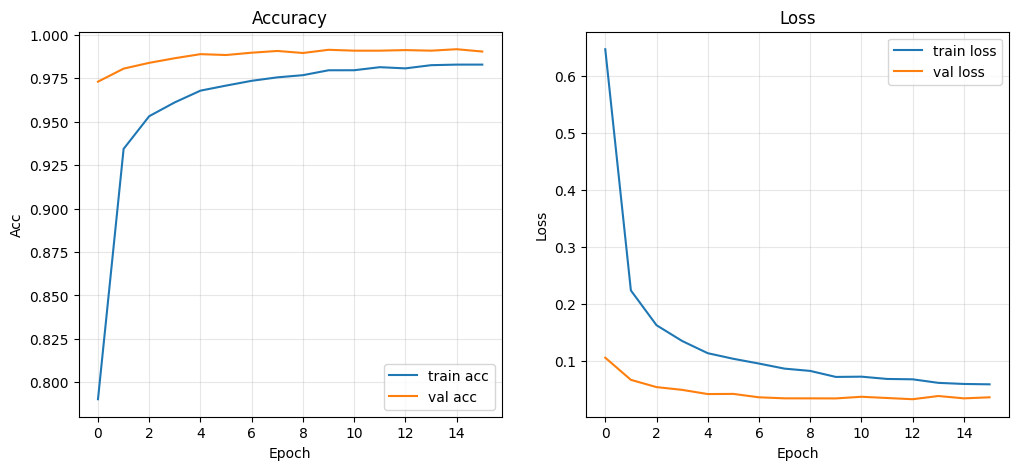

In [34]:
from prompt_toolkit.shortcuts.progress_bar import Label
# 7) 시각화 하기 - 학습 곡선 시각화(정확도 / 손실)
# %matplotlib inline # %매직명령어 중 matplotlib의 show() 처리 - 써도되고 안써도됨.(VSCode에서는 사용X)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist.history['accuracy'], label='train acc')
plt.plot(hist.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Acc')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(hist.history['loss'], label='train loss')
plt.plot(hist.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show() # show없어도 나옴! vscode는 show없으면 안나오니까 왠만하면 쓰기!

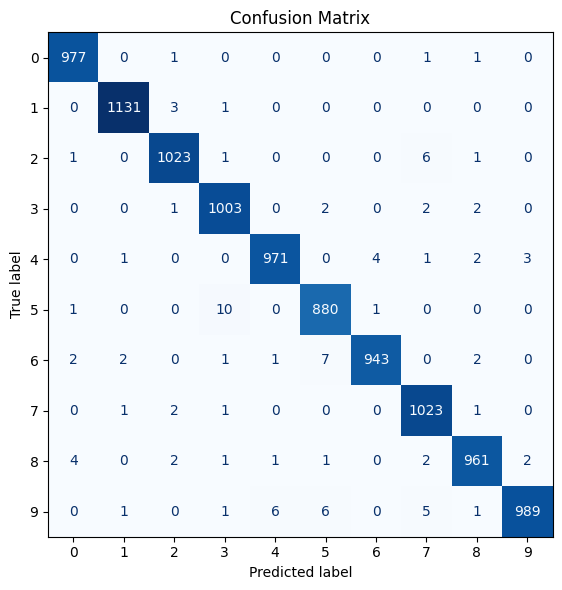

In [39]:
# 8) 혼돈행렬로 출력
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred_all = np.argmax(loaded_model.predict(x_test, verbose=0), axis=1)
cm = confusion_matrix(y_test , y_pred_all, labels=list(range(10)))
# print(cm)
classes = [str(i) for i in range(10)]
disp = ConfusionMatrixDisplay(cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()